# XGBoost GBTree — Hyperparameter Optimization


In [3]:
# !python -m pip install numpy pandas \
#     qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
#     pylatexenc ucimlrepo \
#     xgboost catboost seaborn libsvm-official \
#     jinja2 scikit-optimize tensorflow imbalanced-learn


In [4]:
import sys
import os

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("quantum-multiclass-classification")[0] + "quantum-multiclass-classification"
print(f"Project root: {project_root}")

sys.path.append(os.path.abspath(project_root))

from utils.prepare_data import prepare_data


Project root: c:\`Bioinformatics\quantum-gesang\quantum-multiclass-classification


In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [name for name in sys.modules if name.startswith(package_name)]
    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

reload_package("model")
reload_package("utils")


In [6]:
dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
feature_cols = [
        "MQ3", "TGS822", "TGS2602", "MQ5", "MQ138", "TGS2620",
        "TGS813", "TGS2600", "TGS2611", "TGS2603", "Humidity", "Celsius",
    ]
target_cols = "Kategori"

import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)


,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,46.5,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.4

In [7]:
X = data[feature_cols]
y = data[target_cols]
print(X.shape, y.shape)

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Groups for StratifiedKFold — prevents leakage across folds.
# Many rows share the same Sampling_ID; they must stay within the same fold.
# (Sampling_ID, not Chop_ID: class B has only 2 Chop_ID -> can't make 5 folds.)
groups = data["Sampling_ID"].values
print("n groups:", len(set(groups)))


(10409, 12) (10409,)
n groups: 274


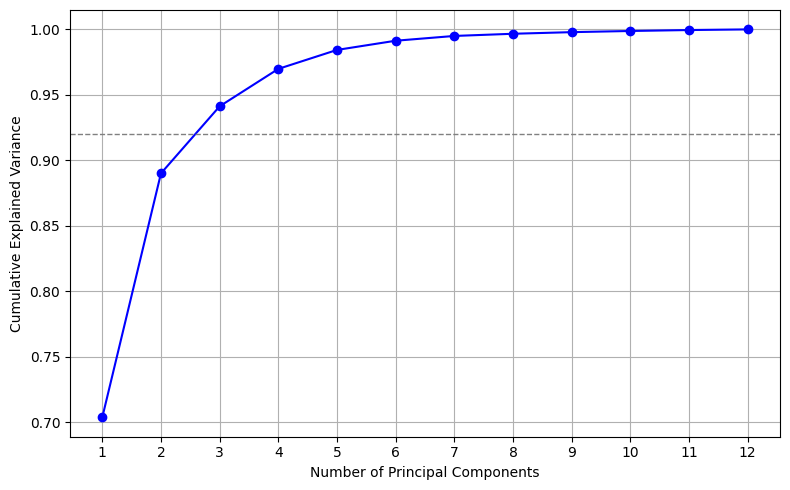

Optimal number of components to retain 92% variance: 3


In [8]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

def plot_pca_variance(X, n_components, threshold=0.95):
    pca = PCA(n_components=n_components)
    pca.fit(X)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_optimal = np.argmax(cumvar >= threshold) + 1

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
    plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.xticks(range(1, n_components + 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')
    return n_optimal

n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.92)


In [9]:
import time, json, pickle
import numpy as np
from pathlib import Path
from datetime import datetime

CATEGORY = "classical"
# Bump when the HPO logic changes in a way that invalidates old checkpoints.
# v2: dropped class_weight/sample_weight balancing + overfit-aware selection.
# v3: added SMOTEENN resampling inside the CV pipeline (train-fold only).
# v4: scoring switched to penalized validation log-loss (minimize), not composite.
# v5: overfit penalty now uses TWO signals — loss_gap + macro-F1 gap.
CKPT_VERSION = 5
HPO_RESULTS = Path(project_root) / "notebooks" / "hpo" / "results"
CSV_DIR  = HPO_RESULTS / "csv" / CATEGORY
LOG_DIR  = HPO_RESULTS / "logs" / CATEGORY
CKPT_DIR = HPO_RESULTS / "checkpoints" / CATEGORY
BEST_DIR = HPO_RESULTS / "best"
FIG_DIR  = HPO_RESULTS / "figures" / CATEGORY
for _d in (CSV_DIR, LOG_DIR, CKPT_DIR, BEST_DIR, FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
    """Call at the start of each section; name is the section slug."""
    global _current_log_path
    _current_log_path = LOG_DIR / f"{name}.log"
    _current_log_path.write_text("")          # fresh log every run
    log(f"📝 Log: {_current_log_path}")
    log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
    print(msg)
    if _current_log_path is not None:
        with open(_current_log_path, "a", encoding="utf-8") as f:
            f.write(str(msg) + "\n")

def _fresh_ckpt():
    # best_score = +inf because selection minimizes penalized log-loss.
    return {"version": CKPT_VERSION, "done_configs": {}, "results": [],
            "best_result": None, "best_score": np.inf}

def load_checkpoint(name):
    """Resume a section; returns an empty skeleton if no (compatible) checkpoint."""
    ckpt_path = CKPT_DIR / f"{name}.pkl"
    if ckpt_path.exists():
        with open(ckpt_path, "rb") as f:
            data = pickle.load(f)
        if data.get("version") != CKPT_VERSION:
            log(f"♻️  Ignoring stale checkpoint (v{data.get('version')} != v{CKPT_VERSION}); starting fresh: {ckpt_path}")
            return _fresh_ckpt(), ckpt_path
        log(f"♻️  Resumed checkpoint: {ckpt_path} ({len(data['done_configs'])} configs done)")
        return data, ckpt_path
    return _fresh_ckpt(), ckpt_path

def save_checkpoint(ckpt_path, data):
    """Atomic save (write .tmp then replace)."""
    data.setdefault("version", CKPT_VERSION)
    tmp = ckpt_path.with_suffix(".pkl.tmp")
    with open(tmp, "wb") as f:
        pickle.dump(data, f)
    tmp.replace(ckpt_path)

def save_best(name, model_label, best_result, extra=None):
    """Persist the section's best result so results.ipynb can aggregate it."""
    payload = {
        "name": name,
        "model": model_label,
        "category": CATEGORY,
        "tag": best_result.get("tag"),
        "loss": best_result.get("loss"),
        "selection_score": best_result.get("selection_score"),
        "train_loss_cv": best_result.get("train_loss_cv"),
        "train_f1macro_cv": best_result.get("train_f1macro_cv"),
        "loss_gap": best_result.get("loss_gap"),
        "f1_gap": best_result.get("f1_gap"),
        "acc": best_result.get("acc"),
        "prec": best_result.get("prec"),
        "rec": best_result.get("rec"),
        "f1": best_result.get("f1"),
        "f1_macro": best_result.get("f1_macro"),
        "roc": best_result.get("roc"),
        "pra": best_result.get("pra"),
        "execution_time": best_result.get("execution_time"),
        "params": best_result.get("params", {}),
    }
    if extra:
        payload.update(extra)
    with open(BEST_DIR / f"{name}.json", "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2, default=str)
    log(f"💾 Best saved: {BEST_DIR / (name + '.json')}")


In [10]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

def plot_fit_diagnostic(build_estimator, params, name, title,
                        normalize_proba=False, fit_kwargs_fn=None,
                        overfit_gap=0.05, low_thresh=0.80):
    """Refit best params per fold, compare TRAIN vs VAL to flag over/underfit."""
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    _fkw = fit_kwargs_fn or (lambda y_tr: {})

    def _scores(model, Xs, ys):
        yp = model.predict(Xs)
        pr = model.predict_proba(Xs)
        if normalize_proba:
            pr = pr / pr.sum(axis=1, keepdims=True)
        a = accuracy_score(ys, yp)
        ll = log_loss(ys, pr, labels=np.unique(y))
        return a, ll

    tr_acc, va_acc, tr_loss, va_loss = [], [], [], []
    for tr, va in skf.split(X, y, groups):
        m = build_estimator(params)
        m.fit(X.iloc[tr], y[tr], **_fkw(y[tr]))
        a1, c1 = _scores(m, X.iloc[tr], y[tr])
        a2, c2 = _scores(m, X.iloc[va], y[va])
        tr_acc.append(a1); va_acc.append(a2); tr_loss.append(c1); va_loss.append(c2)

    tr_acc_m, va_acc_m = float(np.mean(tr_acc)), float(np.mean(va_acc))
    gap = tr_acc_m - va_acc_m
    # Overfit (train >> val) is checked first so a big gap is never masked as
    # "Underfit" just because both means sit below low_thresh.
    if gap > overfit_gap:
        verdict = "Overfit"
    elif va_acc_m < low_thresh:
        verdict = "Underfit"
    else:
        verdict = "Generalized"

    folds = np.arange(1, 6)
    w = 0.35
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].bar(folds - w/2, tr_acc, w, label='Train', color='#4C72B0')
    ax[0].bar(folds + w/2, va_acc, w, label='Validation', color='#DD8452')
    ax[0].axhline(tr_acc_m, color='#4C72B0', ls='--', lw=1)
    ax[0].axhline(va_acc_m, color='#DD8452', ls='--', lw=1)
    ax[0].set_title('Accuracy'); ax[0].set_xlabel('Fold'); ax[0].set_ylim(0, 1.05)
    ax[0].set_xticks(folds); ax[0].legend(); ax[0].grid(axis='y', alpha=0.3)

    ax[1].bar(folds - w/2, tr_loss, w, label='Train', color='#4C72B0')
    ax[1].bar(folds + w/2, va_loss, w, label='Validation', color='#DD8452')
    ax[1].set_title('Log-loss (lower = better)')
    ax[1].set_xlabel('Fold')
    ax[1].set_xticks(folds); ax[1].legend(); ax[1].grid(axis='y', alpha=0.3)

    fig.suptitle(f"{title} — best-param fit: {verdict}  "
                 f"(train acc={tr_acc_m:.3f}, val acc={va_acc_m:.3f}, gap={gap:+.3f})",
                 fontsize=12)
    fig.tight_layout()
    fig_path = FIG_DIR / f"{name}_fit.png"
    fig.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()

    log(f"📈 Fit diagnostic [{title}] → {verdict} "
        f"(train acc={tr_acc_m:.4f} | val acc={va_acc_m:.4f} | gap={gap:+.4f})")
    log(f"🖼️  Figure: {fig_path}")
    return {"fit_verdict": verdict, "train_acc": tr_acc_m,
            "val_acc": va_acc_m, "fit_gap": float(gap)}


## GBTree


In [11]:
# Search Space + estimator builder
import numpy as np

NORMALIZE_PROBA = False

search_space = {
  'n_estimators': [200, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [3, 6],
  'min_child_weight': [1, 10],
  'reg_alpha': [0, 1],
  'reg_lambda': [1, 10],
  'gamma': [0, 1],
}

from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

def build_estimator(params):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_optimal)),
        ('smoteenn', SMOTEENN(random_state=42)),  # train-fold only (no leak)
        ('xgb', XGBClassifier(booster='gbtree', objective='multi:softprob',
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, device='cuda', **params)),
    ])

fit_kwargs_fn = lambda y_tr: {}


In [ ]:
setup_logger("xgb_gbtree")
from sklearn.model_selection import StratifiedKFold
from itertools import product
import time
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef,
    precision_score, recall_score, log_loss,
)

state = 42
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

classes = np.unique(y)

# Primary scoring = mean validation LOG-LOSS (lower is better). Overfit is checked
# with TWO signals, each penalized only beyond its own tolerance:
#   loss_gap = val_loss - train_loss        -> probability calibration
#   f1_gap   = train_macroF1 - val_macroF1  -> per-class balance (catches minority overfit)
#   penalty  = W_LOSS*max(0, loss_gap - TOL_LOSS) + W_F1*max(0, f1_gap - TOL_F1)
#   selection_score = val_loss + penalty    -> best config = the MINIMUM
# Train metrics are measured on the ORIGINAL (non-resampled) train fold.
TOL_LOSS = 0.05   # "free" train-val log-loss gap (no penalty below this)
TOL_F1   = 0.05   # "free" train-val macro-F1 gap
W_LOSS   = 1.0    # weight for the log-loss overfit signal
W_F1     = 1.0    # weight for the macro-F1 overfit signal

param_keys = list(search_space.keys())
param_vals = list(search_space.values())
search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = int(np.prod([len(v) for v in param_vals]))
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: mean validation log-loss (lower better); overfit penalty on loss_gap + macroF1_gap")
log(f"   Overfit guard: +{W_LOSS}×max(0, loss_gap - {TOL_LOSS}) +{W_F1}×max(0, f1_gap - {TOL_F1})")

ckpt, ckpt_path = load_checkpoint("xgb_gbtree")
done_configs = ckpt["done_configs"]
results      = ckpt["results"]
best_result  = ckpt["best_result"]
best_score   = ckpt["best_score"]

for i, comb in enumerate(product(*param_vals)):
    params = dict(zip(param_keys, comb))
    tag = " | ".join(f"{k}={v}" for k, v in params.items())

    if tag in done_configs:
        log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
        continue

    log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
    _iter_t0 = time.perf_counter()

    accs, f1s, f1ms, rocs, pras, precs, recs, lls = [], [], [], [], [], [], [], []
    tr_lls, tr_f1ms = [], []
    y_val_all, y_pred_all = [], []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y, groups), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = build_estimator(params)
        model.fit(X_train, y_train, **fit_kwargs_fn(y_train))

        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)
        if NORMALIZE_PROBA:
            y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)

        # Train log-loss + macro-F1 (original train fold) for the overfit checks
        tr_prob = model.predict_proba(X_train)
        if NORMALIZE_PROBA:
            tr_prob = tr_prob / tr_prob.sum(axis=1, keepdims=True)
        tr_lls.append(log_loss(y_train, tr_prob, labels=classes))
        # use model.predict (not argmax of proba) so train f1 matches how val f1 is computed
        tr_f1ms.append(f1_score(y_train, model.predict(X_train), average='macro'))

        y_val_all.extend(y_val)
        y_pred_all.extend(y_pred)

        acc  = accuracy_score(y_val, y_pred)
        f1   = f1_score(y_val, y_pred, average='weighted')
        f1m  = f1_score(y_val, y_pred, average='macro')
        roc  = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
        pra  = average_precision_score(y_val, y_prob, average='weighted')
        prec = precision_score(y_val, y_pred, average='weighted')
        rec  = recall_score(y_val, y_pred, average='weighted')
        ll   = log_loss(y_val, y_prob, labels=classes)

        accs.append(acc); f1s.append(f1); f1ms.append(f1m); rocs.append(roc)
        pras.append(pra); precs.append(prec); recs.append(rec); lls.append(ll)

        log(f"    F{fold} → Loss={ll:.4f} | Acc={acc:.4f} | F1w={f1:.4f} | F1m={f1m:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

        results.append({
            "tag": tag, **params, "fold": fold,
            "accuracy": acc, "precision": prec, "recall": rec,
            "F1": f1, "f1_macro": f1m, "auroc": roc, "prauc": pra,
            "loss": ll, "train_loss": tr_lls[-1],
        })

    acc_mean,  acc_std  = np.mean(accs),  np.std(accs)
    prec_mean, prec_std = np.mean(precs), np.std(precs)
    rec_mean,  rec_std  = np.mean(recs),  np.std(recs)
    f1_mean,   f1_std   = np.mean(f1s),   np.std(f1s)
    f1m_mean,  f1m_std  = np.mean(f1ms),  np.std(f1ms)
    roc_mean,  roc_std  = np.mean(rocs),  np.std(rocs)
    pra_mean,  pra_std  = np.mean(pras),  np.std(pras)
    loss_mean, loss_std = np.mean(lls),   np.std(lls)
    mcc = matthews_corrcoef(y_val_all, y_pred_all)

    # Overfit-aware selection: MINIMIZE val log-loss, penalize TWO overfit signals:
    #   loss_gap = val_loss - train_loss ; f1_gap = train_macroF1 - val_macroF1
    tr_loss_mean = float(np.mean(tr_lls))
    tr_f1m_mean  = float(np.mean(tr_f1ms))
    loss_gap = loss_mean - tr_loss_mean
    f1_gap   = tr_f1m_mean - f1m_mean
    penalty  = W_LOSS * max(0.0, loss_gap - TOL_LOSS) + W_F1 * max(0.0, f1_gap - TOL_F1)
    selection_score = loss_mean + penalty
    overfit_flag = " ⚠️ OVERFIT" if (loss_gap > TOL_LOSS or f1_gap > TOL_F1) else ""

    log(
        f"  ✅  Loss:{loss_mean:.4f}±{loss_std:.4f} | "
        f"Acc:{acc_mean:.4f}±{acc_std:.4f} | "
        f"F1w:{f1_mean:.4f}±{f1_std:.4f} | "
        f"F1macro:{f1m_mean:.4f}±{f1m_std:.4f} | "
        f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
        f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
        f"MCC:{mcc:.4f}"
    )
    log(
        f"      ↳ LossGap:{loss_gap:+.4f} (tr {tr_loss_mean:.4f}) | "
        f"F1macroGap:{f1_gap:+.4f} (tr {tr_f1m_mean:.4f}) | "
        f"Penalty:{penalty:.4f} | Selection(loss):{selection_score:.4f}{overfit_flag}"
    )

    iter_time = time.perf_counter() - _iter_t0
    if best_score is None or selection_score < best_score:
        best_score = selection_score
        best_result = {
            'tag': tag,
            'loss': f"{loss_mean:.4f}±{loss_std:.4f}",
            'selection_score': selection_score,
            'train_loss_cv': f"{tr_loss_mean:.4f}",
            'train_f1macro_cv': f"{tr_f1m_mean:.4f}",
            'loss_gap': f"{loss_gap:+.4f}",
            'f1_gap': f"{f1_gap:+.4f}",
            'acc':  f"{acc_mean:.4f}±{acc_std:.4f}",
            'f1':   f"{f1_mean:.4f}±{f1_std:.4f}",
            'f1_macro': f"{f1m_mean:.4f}±{f1m_std:.4f}",
            'roc':  f"{roc_mean:.4f}±{roc_std:.4f}",
            'pra':  f"{pra_mean:.4f}±{pra_std:.4f}",
            'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
            'rec':  f"{rec_mean:.4f}±{rec_std:.4f}",
            'params': params, 'execution_time': iter_time,
        }

    done_configs[tag] = {"loss": loss_mean, "selection_score": selection_score,
                         "loss_gap": loss_gap, "f1_gap": f1_gap, "params": params}
    save_checkpoint(ckpt_path, {
        "version": CKPT_VERSION,
        "done_configs": done_configs, "results": results,
        "best_result": best_result, "best_score": best_score,
    })

log(f"\n🏆 Best config : {best_result['tag']}  (min penalized log-loss)")
log(
    f"   Log-loss    : {best_result['loss']} "
    f"(Acc={best_result['acc']} | F1w={best_result['f1']} | F1macro={best_result['f1_macro']} | "
    f"AUROC={best_result['roc']} | PRAUC={best_result['pra']})"
)
log(
    f"   Selection   : {best_result['selection_score']:.4f} "
    f"(LossGap={best_result['loss_gap']} | F1macroGap={best_result['f1_gap']})"
)


📝 Log: c:\`Bioinformatics\quantum-gesang\quantum-multiclass-classification\notebooks\hpo\results\logs\classical\xgb_gbtree.log
🕒 Started: 2026-06-08T09:11:33
🔬 Search space: 2 n_estimators × 2 learning_rate × 2 max_depth × 2 min_child_weight × 2 reg_alpha × 2 reg_lambda × 2 gamma =  128 configs × 5 folds = 640 fits
   Scoring criterion: mean validation log-loss (lower better); overfit penalty on loss_gap + macroF1_gap
   Overfit guard: +1.0×max(0, loss_gap - 0.02) +1.0×max(0, f1_gap - 0.02)
♻️  Ignoring stale checkpoint (v4 != v5); starting fresh: c:\`Bioinformatics\quantum-gesang\quantum-multiclass-classification\notebooks\hpo\results\checkpoints\classical\xgb_gbtree.pkl

  ▶ [1/128] n_estimators=200 | learning_rate=0.01 | max_depth=3 | min_child_weight=1 | reg_alpha=0 | reg_lambda=1 | gamma=0
    F1 → Loss=0.9751 | Acc=0.7272 | F1w=0.7351 | F1m=0.6948 | AUROC=0.9264 | PRAUC=0.8351
    F2 → Loss=0.9687 | Acc=0.7402 | F1w=0.7458 | F1m=0.7209 | AUROC=0.9306 | PRAUC=0.8428
    F3 → Loss=

In [ ]:
import pandas as pd
df = pd.DataFrame(results)
filename = CSV_DIR / "xgb_gbtree_hpo.csv"
df.to_csv(filename, index=False)
log(f"✅ Saved: {filename}")


In [ ]:
# 📈 Best-param fit diagnostic (overfit / underfit / generalized)
fit_info = plot_fit_diagnostic(
    build_estimator, best_result['params'],
    name="xgb_gbtree", title="XGBoost GBTree", normalize_proba=NORMALIZE_PROBA,
    fit_kwargs_fn=fit_kwargs_fn,
)


In [ ]:
best_result['model'] = "XGBoost GBTree"
save_best("xgb_gbtree", "XGBoost GBTree", best_result, extra={'variant': 'xgboost', **fit_info})
log(f"✅ [XGBoost GBTree] recorded | Exec. time: {best_result['execution_time']:.1f}s")
